In [47]:
import json
import os

import numpy as np
import pandas as pd

#dir = '../large_files/new_beam_matching_experiment_1nrec'
dir = '../data/results/experiments/new_beam_matching_experiment_23'

data_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

data_df['n_best_pcis'] = data_df['n_best_pcis'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')
data_df['n_best_beams'] = data_df['n_best_beams'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')


#data_df['runtime'] = data_df['runtime'] * 1000 / 2500


def get_strat(row):
    if row['n_best_pcis'] == 'all' and row['n_best_beams'] == 'all':
        return 'All PCIs and all beams'
    elif row['n_best_pcis'] == '1' and row['n_best_beams'] == 'all':
        return 'Only best PCI and all beams'
    elif row['n_best_pcis'] == 'all' and row['n_best_beams'] == '1':
        return 'All PCIs and only best beam'
    elif row['n_best_pcis'] == '1' and row['n_best_beams'] == '1':
        return 'Only best PCI and only best beam'
    return 'unknown strategy'


data_df['config'] = data_df.apply(get_strat, axis=1)

data_df

,errors,complexity,runtime,n_tps,mnc,run,n_best_pcis,n_best_beams,config
0,9.030282,21042.0,0.766138,2515.0,0.0,0.0,1,1,Only best PCI and only best beam
1,32.694350,21042.0,0.766138,2515.0,0.0,0.0,1,1,Only best PCI and only best beam
2,20.608276,21042.0,0.766138,2515.0,0.0,0.0,1,1,Only best PCI and only best beam
3,37.639838,21042.0,0.766138,2515.0,0.0,0.0,1,1,Only best PCI and only best beam
4,10.115961,21042.0,0.766138,2515.0,0.0,0.0,1,1,Only best PCI and only best beam
...,...,...,...,...,...,...,...,...,...
2022395,0.232444,181475.0,14.126047,2537.0,0.0,4.0,20,8,unknown strategy
2022396,1.424988,181475.0,14.126047,2537.0,0.0,4.0,20,8,unknown strategy
2022397,5.983536,181475.0,14.126047,2537.0,0.0,4.0,20,8,unknown strategy
2022398,8.757346,181475.0,14.126047,2537.0,0.0,4.0,20,8,unknown strategy


In [55]:
# res = []
# for group, data in data_df.groupby(['n_best_pcis', 'n_best_beams']):
#     errors = data.groupby('run')['errors'].mean().values
#     complexity = data.groupby('run')['complexity'].mean().values
#     print(group)
#     for i in range(errors.shape[0]):
#         res.append((group[0], group[1], errors[i], complexity[i]))
#
# order = [str(x) for x in range(1, 20)] + ['all']
#
# df = pd.DataFrame(res,
#                   columns=['n_best_pcis', 'n_best_beams', 'errors', 'complexity'])
# df['n_best_pcis'] = pd.Categorical(df['n_best_pcis'], categories=order, ordered=True)
# df.sort_values(by=['n_best_pcis', 'n_best_beams'], inplace=True)
#
# df[df['n_best_pcis'] == 'all']['errors'].mean()

res = []
for group, data in data_df.groupby(['n_best_pcis', 'n_best_beams', 'mnc', 'config']):
    errors = data.groupby('run')['errors'].mean().values
    complexity = data.groupby('run')['complexity'].mean().values
    runtime = data.groupby('run')['runtime'].mean().values

    for i in range(errors.shape[0]):
        res.append((group[0], group[1], group[2], errors[i], complexity[i], group[3], runtime[i]))

order = [str(x) for x in range(1, 21)] + ['all']

df = pd.DataFrame(res,
                  columns=['n_best_pcis', 'n_best_beams', 'mnc', 'errors', 'complexity', 'config', 'runtime'])
df['n_best_pcis'] = pd.Categorical(df['n_best_pcis'], categories=order, ordered=True)
df.sort_values(by=['n_best_pcis', 'n_best_beams'], inplace=True)

df[df['n_best_pcis'] == 'all']['errors'].mean()

df.groupby(['mnc', 'config'])['errors'].mean()

mnc  config                          
0.0  Only best PCI and only best beam    17.523213
     unknown strategy                     8.081158
Name: errors, dtype: float64

/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_27317/4075178011.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lows['n_best_pcis'] = pd.Categorical(df_lows['n_best_pcis'], categories=lows, ordered=True)
/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_27317/4075178011.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_highs['n_best_pcis'] = pd.Categorical(df_highs['n_best_pcis'], categories=highs, ordered=True)


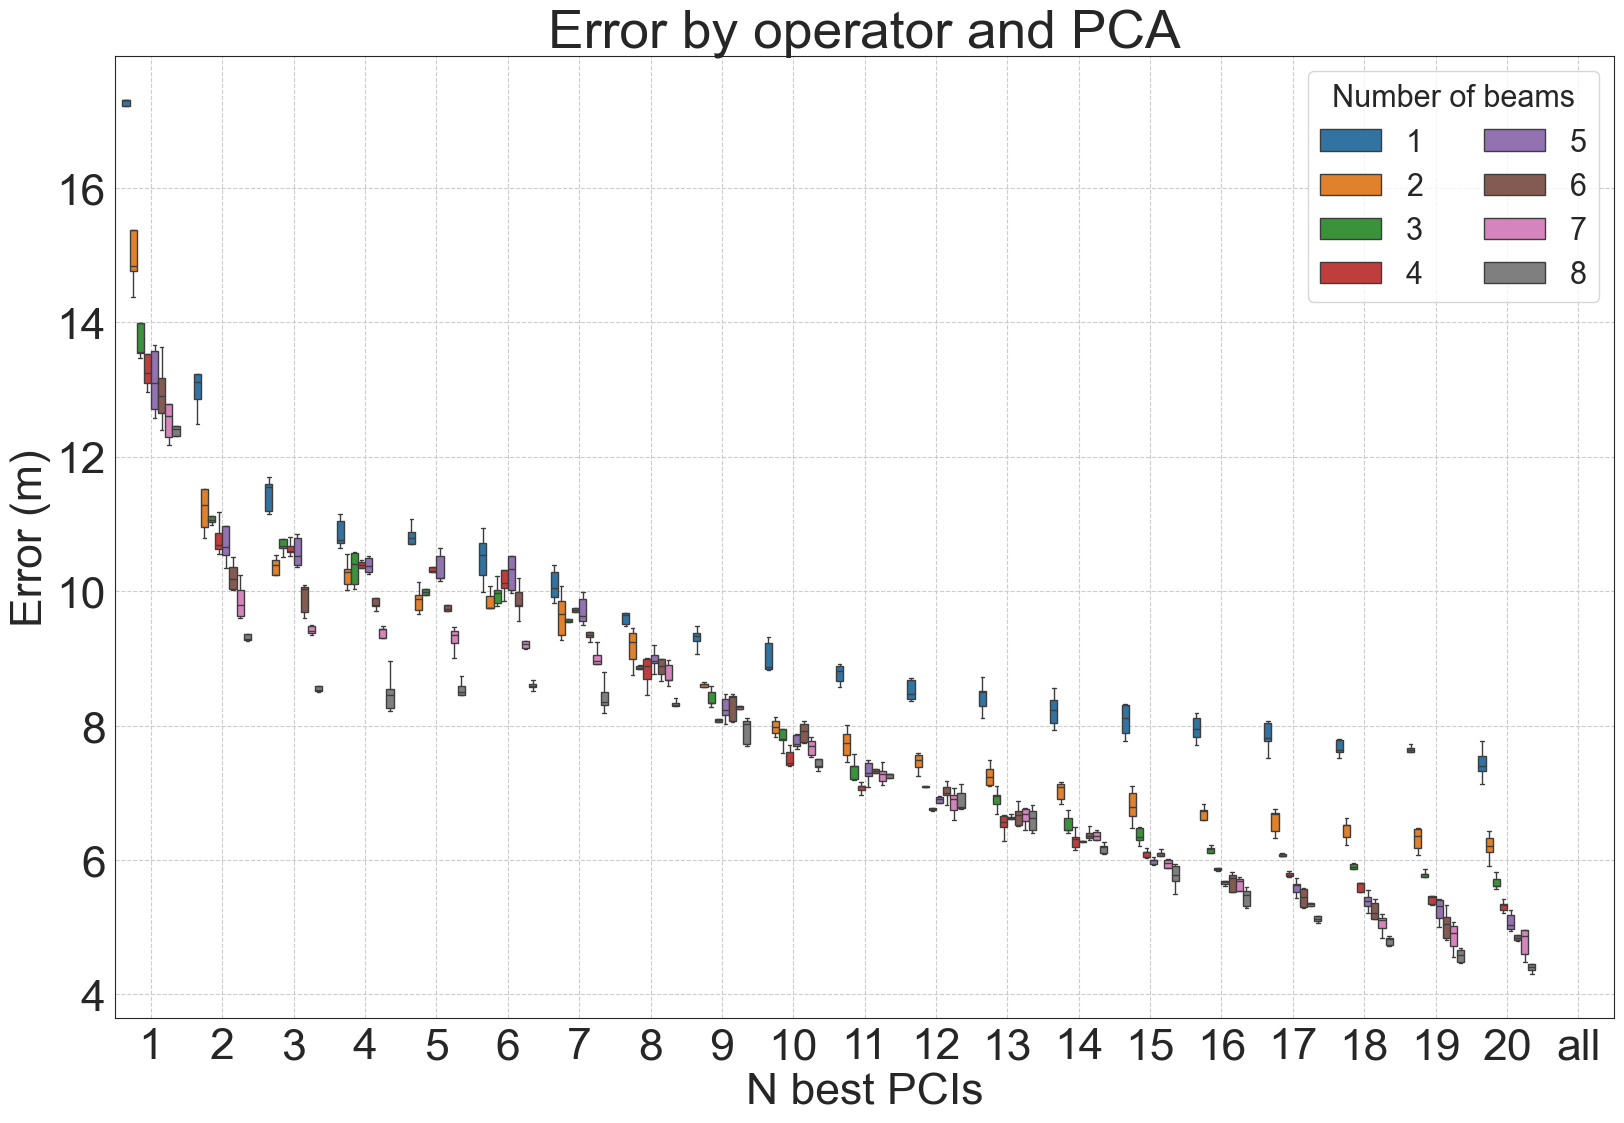

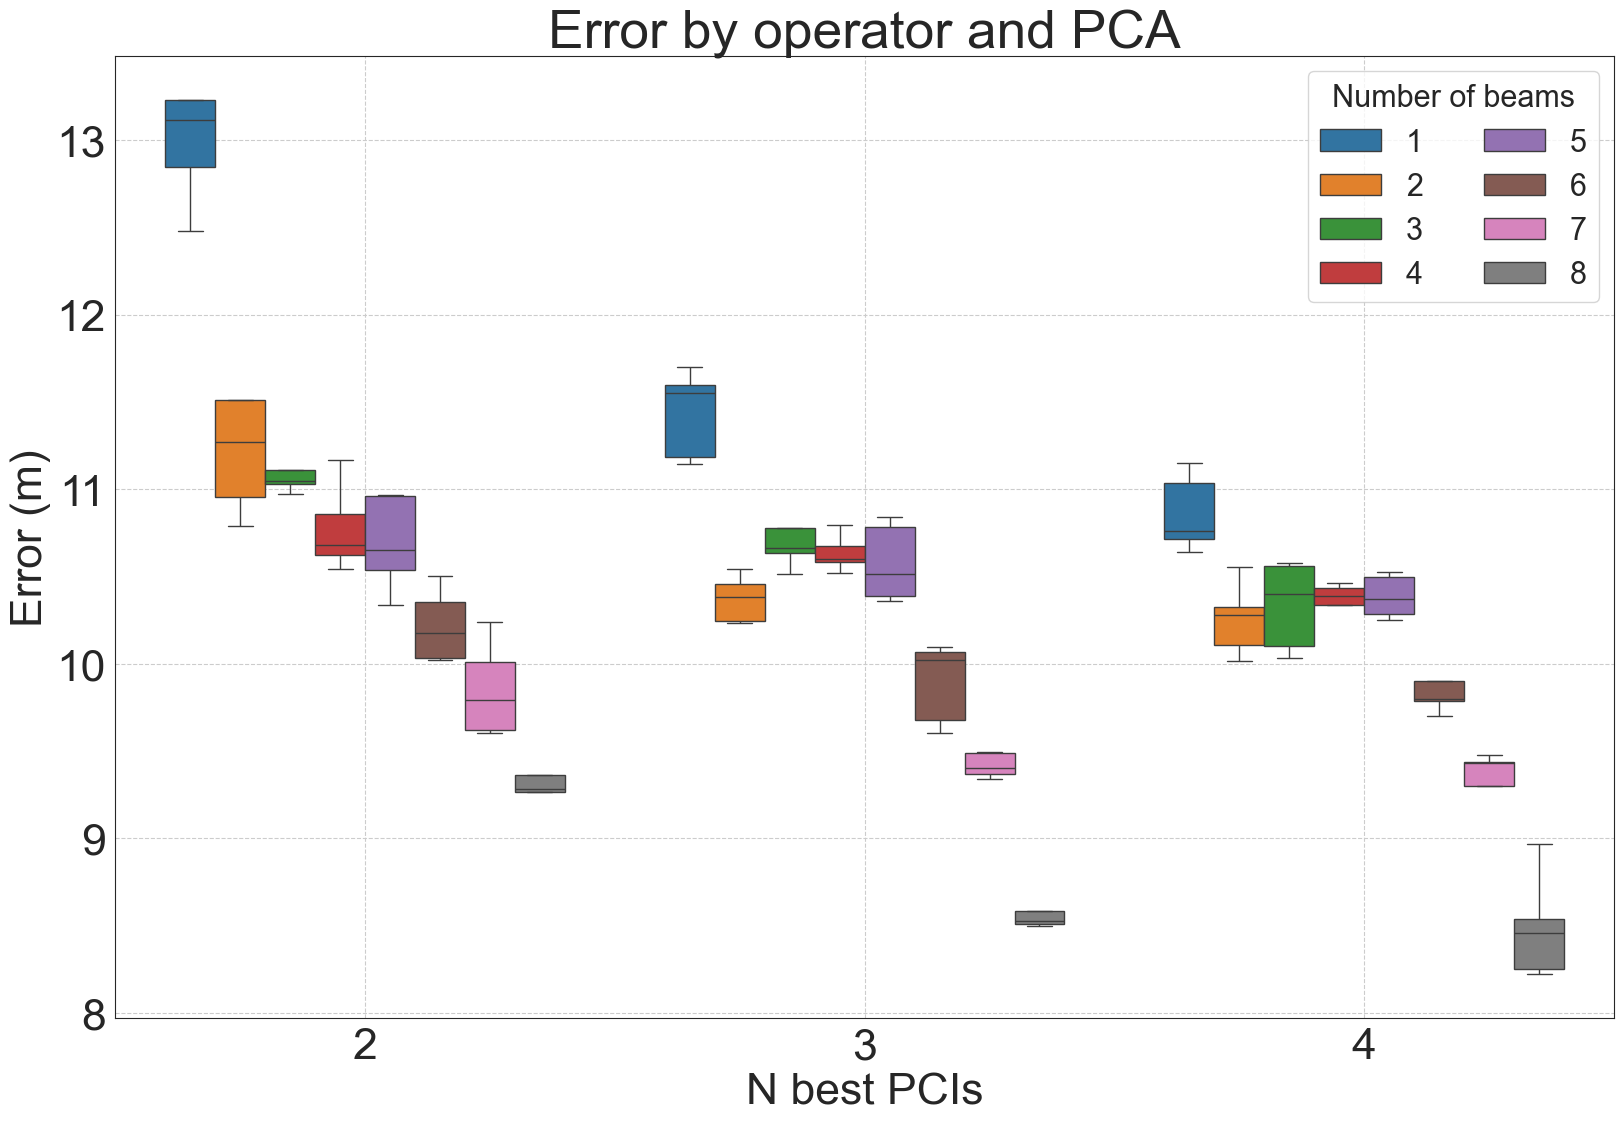

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 32})

    # baseline = df[df['n_best_pcis'] == 'all']['errors'].mean()
    #
    # data = df[df['n_best_pcis'] != 'all']

    plt.figure(figsize=(17, 12))
    sns.set_style("white")
    sns.boxplot(
        data=df,
        x='n_best_pcis',
        y='errors',
        hue='n_best_beams',
        showfliers=False,
    )
    # Add labels and title
    plt.xlabel('N best PCIs')
    plt.ylabel('Error (m)')
    plt.title('Error by operator and PCA')

    plt.legend(title='Number of beams', loc='upper right', fontsize=22, ncol=2, title_fontsize=22)
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


#plot(df[df['n_best_pcis'] == 9])

highs = [str(i) for i in range(10, 21)] + ['all']
lows = [str(i) for i in range(2, 5)]


#plot(data_df[data_df['n_best_pcis'].isin(highs)])
#plot(data_df[data_df['n_best_pcis'].isin(lows)])

def do_plot(df):
    df_lows = df[df['n_best_pcis'].isin(lows)]
    df_lows['n_best_pcis'] = pd.Categorical(df_lows['n_best_pcis'], categories=lows, ordered=True)

    df_highs = df[df['n_best_pcis'].isin(highs)]
    df_highs['n_best_pcis'] = pd.Categorical(df_highs['n_best_pcis'], categories=highs, ordered=True)

    # plot the points
    plot(df)
    plot(df_lows)
    # plot(df_highs)


df['n_best_beams'] = df['n_best_beams'].apply(lambda x: x if x != 'all' else '8')

do_plot(df)

/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_27317/2707243163.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


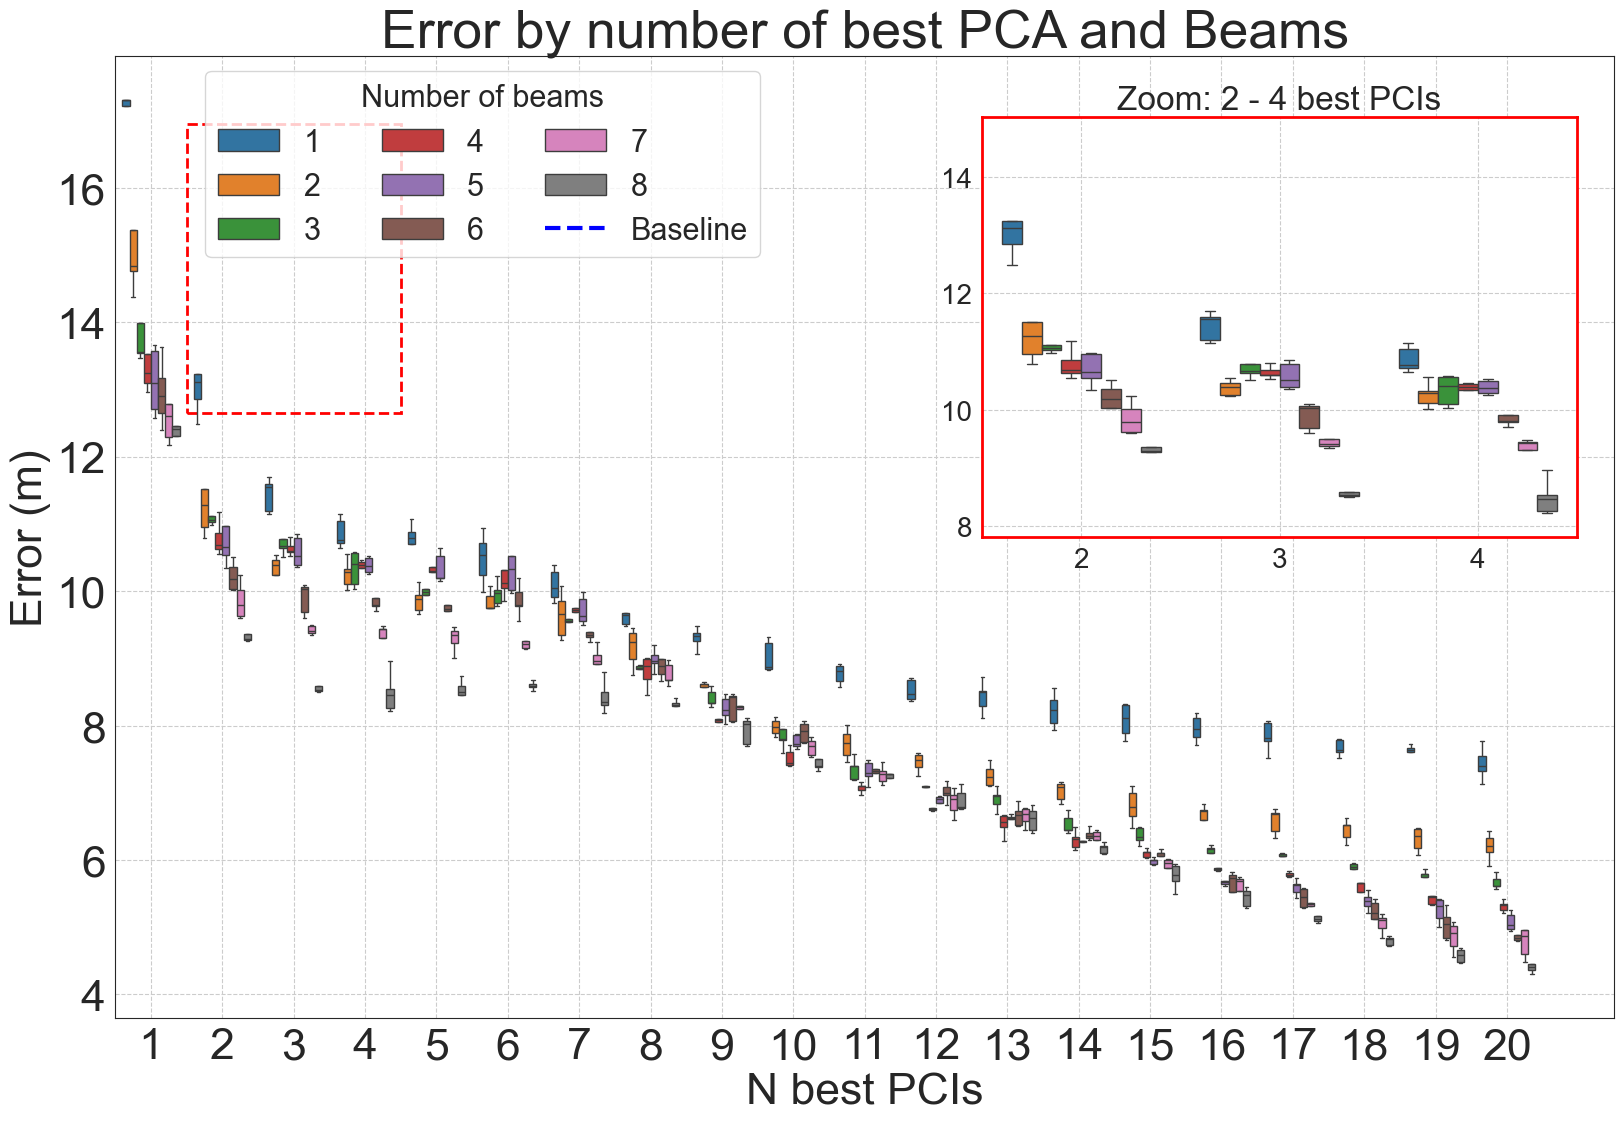

In [60]:
def plot(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 32})

    # Create the main figure and axes
    fig, ax = plt.subplots(figsize=(17, 12))
    sns.set_style("white")

    mask_all = df['n_best_pcis'] == 'all'
    df_all = df[mask_all]
    df_rest = df[~mask_all]

    baseline = df_all['errors'].mean()

    # Create the main boxplot with only non-'all' data
    sns.boxplot(
        data=df_rest,
        x='n_best_pcis',
        y='errors',
        hue='n_best_beams',
        showfliers=False,
        ax=ax
    )

    # Add the baseline as a horizontal blue dashed line
    baseline_line = ax.axhline(y=baseline, color='blue', linestyle='--', linewidth=3)

    # Add labels and title
    ax.set_xlabel('N best PCIs')
    ax.set_ylabel('Error (m)')
    ax.set_title('Error by number of best PCA and Beams')

    # Explicitly set the x-tick labels to exclude 'all'
    current_xticks = ax.get_xticks()
    current_xticklabels = [label.get_text() for label in ax.get_xticklabels()]

    # Filter out 'all' if it exists in the labels
    filtered_xticks = []
    filtered_xticklabels = []
    for i, label in enumerate(current_xticklabels):
        if label != 'all':
            filtered_xticks.append(current_xticks[i])
            filtered_xticklabels.append(label)

    ax.set_xticks(filtered_xticks)
    ax.set_xticklabels(filtered_xticklabels)

    # Add legend to the main plot, including the baseline line
    handles, labels = ax.get_legend_handles_labels()
    handles.append(baseline_line)
    labels.append('Baseline')
    ax.legend(handles=handles, labels=labels, title='Number of beams',
              loc='upper left', fontsize=22, ncol=3, title_fontsize=22, bbox_to_anchor=(0.05, 1.0),
              # x=0.15 moves right, y=1.0 positions at top
              )

    ax.grid(linestyle='--')

    # Create an inset axes for the zoomed region
    axins = fig.add_axes([0.6, 0.52, 0.35, 0.35])

    # Create the same boxplot in the inset, but it will be zoomed
    axi = sns.boxplot(
        data=df_rest,
        x='n_best_pcis',
        y='errors',
        hue='n_best_beams',
        showfliers=False,
        ax=axins
    )

    # No baseline line in the small plot as requested

    axi.set_ylabel('')
    axi.grid(linestyle='--')

    # Set the x-limits to focus on n_best_pcis from 2-4
    all_categories = df_rest['n_best_pcis'].unique()

    # Find indices of categories '2', '3', and '4'
    try:
        idx_2 = list(all_categories).index('2')
        idx_3 = list(all_categories).index('3')
        idx_4 = list(all_categories).index('4')
        axins.set_xlim(idx_2 - 0.5, idx_4 + 0.5)
    except (ValueError, TypeError):
        # If categories are numeric, not strings
        axins.set_xlim(1.5, 4.5)

    # Adjust y-limits for the zoomed area
    subset = df_rest[df_rest['n_best_pcis'].isin(['2', '3', '4'])]
    y_min = subset['errors'].min() * 0.95
    y_max = subset['errors'].max() * 1.05
    axins.set_ylim(y_min, y_max)
    axins.tick_params(axis='both', which='major', labelsize=32)
    for spine in axins.spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(2)

    # Remove legend from inset to avoid clutter
    axins.get_legend().remove()

    # Mark the zoomed region in the main plot
    from matplotlib.patches import Rectangle

    # Get the position of the categories in the main plot
    try:
        x_min = idx_2 - 0.5
        x_max = idx_4 + 0.5
    except (ValueError, TypeError, NameError):
        x_min = 1.5
        x_max = 4.5

    # Get the full y-range of the main plot
    main_y_min, main_y_max = ax.get_ylim()

    rect_y_min = main_y_min
    rect_height = (main_y_max - main_y_min) * 0.3

    rect = Rectangle((x_min, rect_y_min + 9), x_max - x_min, rect_height,
                     fill=False, edgecolor='red', linestyle='--', linewidth=2)
    ax.add_patch(rect)

    # Update the title for the inset
    axins.set_title('Zoom: 2 - 4 best PCIs', fontsize=24)

    # Adjust labels on inset
    axins.set_xlabel('')
    axins.tick_params(axis='both', which='major', labelsize=20)

    plt.tight_layout()
    plt.show()


plot(df)


/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_27317/1551462338.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


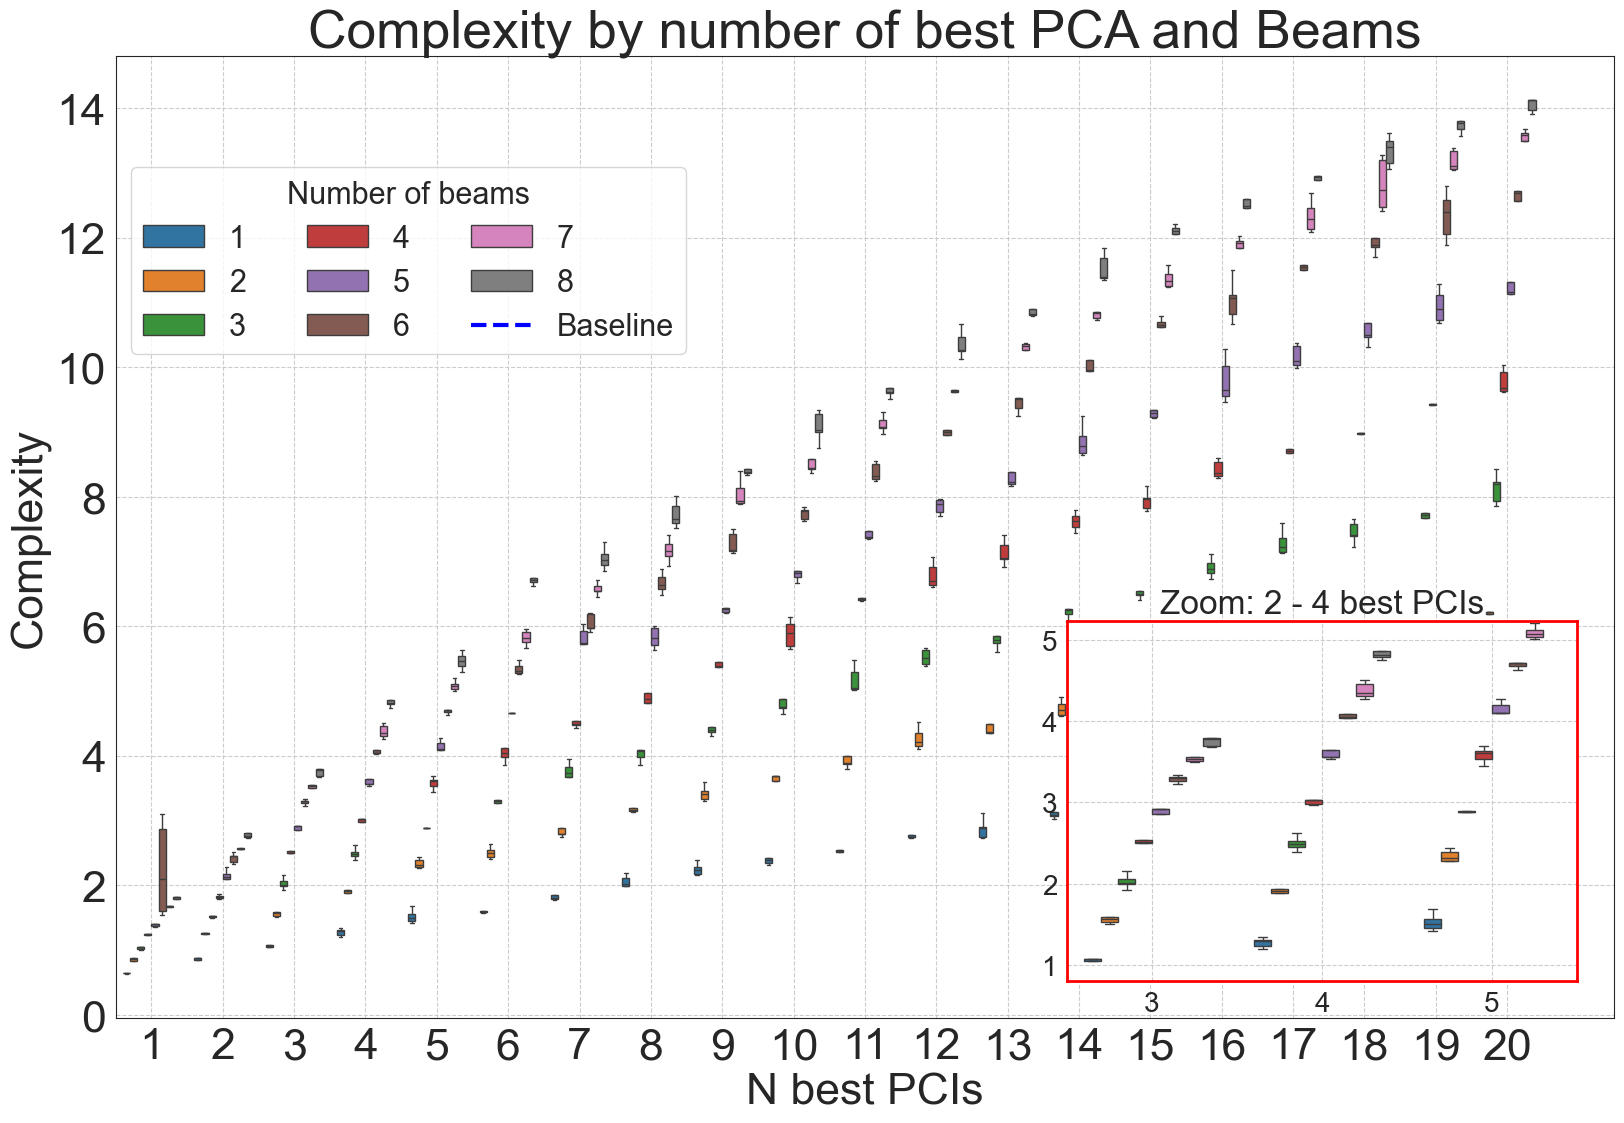

In [62]:
def plot(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 32})

    # Create the main figure and axes
    fig, ax = plt.subplots(figsize=(17, 12))
    sns.set_style("white")

    mask_all = df['n_best_pcis'] == 'all'
    df_all = df[mask_all]
    df_rest = df[~mask_all]

    baseline = df_all['runtime'].mean()

    # Create the main boxplot with only non-'all' data
    sns.boxplot(
        data=df_rest,
        x='n_best_pcis',
        y='runtime',
        hue='n_best_beams',
        showfliers=False,
        ax=ax
    )

    # Add the baseline as a horizontal blue dashed line
    baseline_line = ax.axhline(y=baseline, color='blue', linestyle='--', linewidth=3)

    # Add labels and title
    ax.set_xlabel('N best PCIs')
    ax.set_ylabel('Complexity')
    ax.set_title('Complexity by number of best PCA and Beams')

    # Explicitly set the x-tick labels to exclude 'all'
    current_xticks = ax.get_xticks()
    current_xticklabels = [label.get_text() for label in ax.get_xticklabels()]

    # Filter out 'all' if it exists in the labels
    filtered_xticks = []
    filtered_xticklabels = []
    for i, label in enumerate(current_xticklabels):
        if label != 'all':
            filtered_xticks.append(current_xticks[i])
            filtered_xticklabels.append(label)

    ax.set_xticks(filtered_xticks)
    ax.set_xticklabels(filtered_xticklabels)

    def thousands_formatter(x, pos):
        return f'{x / 1000:,.0f}k' if x >= 1000 else f'{x:,.0f}'

    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    # Add legend to the main plot, including the baseline line
    handles, labels = ax.get_legend_handles_labels()
    handles.append(baseline_line)
    labels.append('Baseline')
    ax.legend(handles=handles, labels=labels, title='Number of beams',
              loc='upper left', fontsize=22, ncol=3, title_fontsize=22, bbox_to_anchor=(0.0, 0.9),
              # x=0.15 moves right, y=1.0 positions at top
              )

    ax.grid(linestyle='--')

    # Create an inset axes for the zoomed region
    axins = fig.add_axes([0.65, 0.15, 0.3, 0.3])

    # Create the same boxplot in the inset, but it will be zoomed
    axi = sns.boxplot(
        data=df_rest,
        x='n_best_pcis',
        y='runtime',
        hue='n_best_beams',
        showfliers=False,
        ax=axins
    )

    # No baseline line in the small plot as requested
    axi.set_ylabel('')
    axi.grid(linestyle='--')
    axi.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    # Set the x-limits to focus on n_best_pcis from 2-4
    all_categories = df_rest['n_best_pcis'].unique()

    # Find indices of categories '2', '3', and '4'
    try:
        idx_2 = list(all_categories).index('3')
        idx_3 = list(all_categories).index('4')
        idx_4 = list(all_categories).index('5')
        axins.set_xlim(idx_2 - 0.5, idx_4 + 0.5)
    except (ValueError, TypeError):
        # If categories are numeric, not strings
        axins.set_xlim(1.5, 4.5)

    # Adjust y-limits for the zoomed area
    subset = df_rest[df_rest['n_best_pcis'].isin(['2', '3', '4'])]
    y_min = subset['runtime'].min() * 0.95
    y_max = subset['runtime'].max() * 1.05
    axins.set_ylim(y_min, y_max)
    axins.tick_params(axis='both', which='major', labelsize=32)

    for spine in axins.spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(2)

    # Remove legend from inset to avoid clutter
    axins.get_legend().remove()

    # Mark the zoomed region in the main plot
    from matplotlib.patches import Rectangle

    # Get the position of the categories in the main plot
    try:
        x_min = idx_2 - 0.5
        x_max = idx_4 + 0.5
    except (ValueError, TypeError, NameError):
        x_min = 1.5
        x_max = 4.5

    # Get the full y-range of the main plot
    main_y_min, main_y_max = ax.get_ylim()

    rect_y_min = main_y_min
    rect_height = (main_y_max - main_y_min) * 0.45

    rect = Rectangle((x_min, 500000), x_max - x_min, rect_height,
                     fill=False, edgecolor='red', linestyle='--', linewidth=2)
    ax.add_patch(rect)

    # Update the title for the inset
    axins.set_title('Zoom: 2 - 4 best PCIs', fontsize=24)

    # Adjust labels on inset
    axins.set_xlabel('')
    axins.tick_params(axis='both', which='major', labelsize=20)

    plt.tight_layout()
    plt.show()


plot(df)


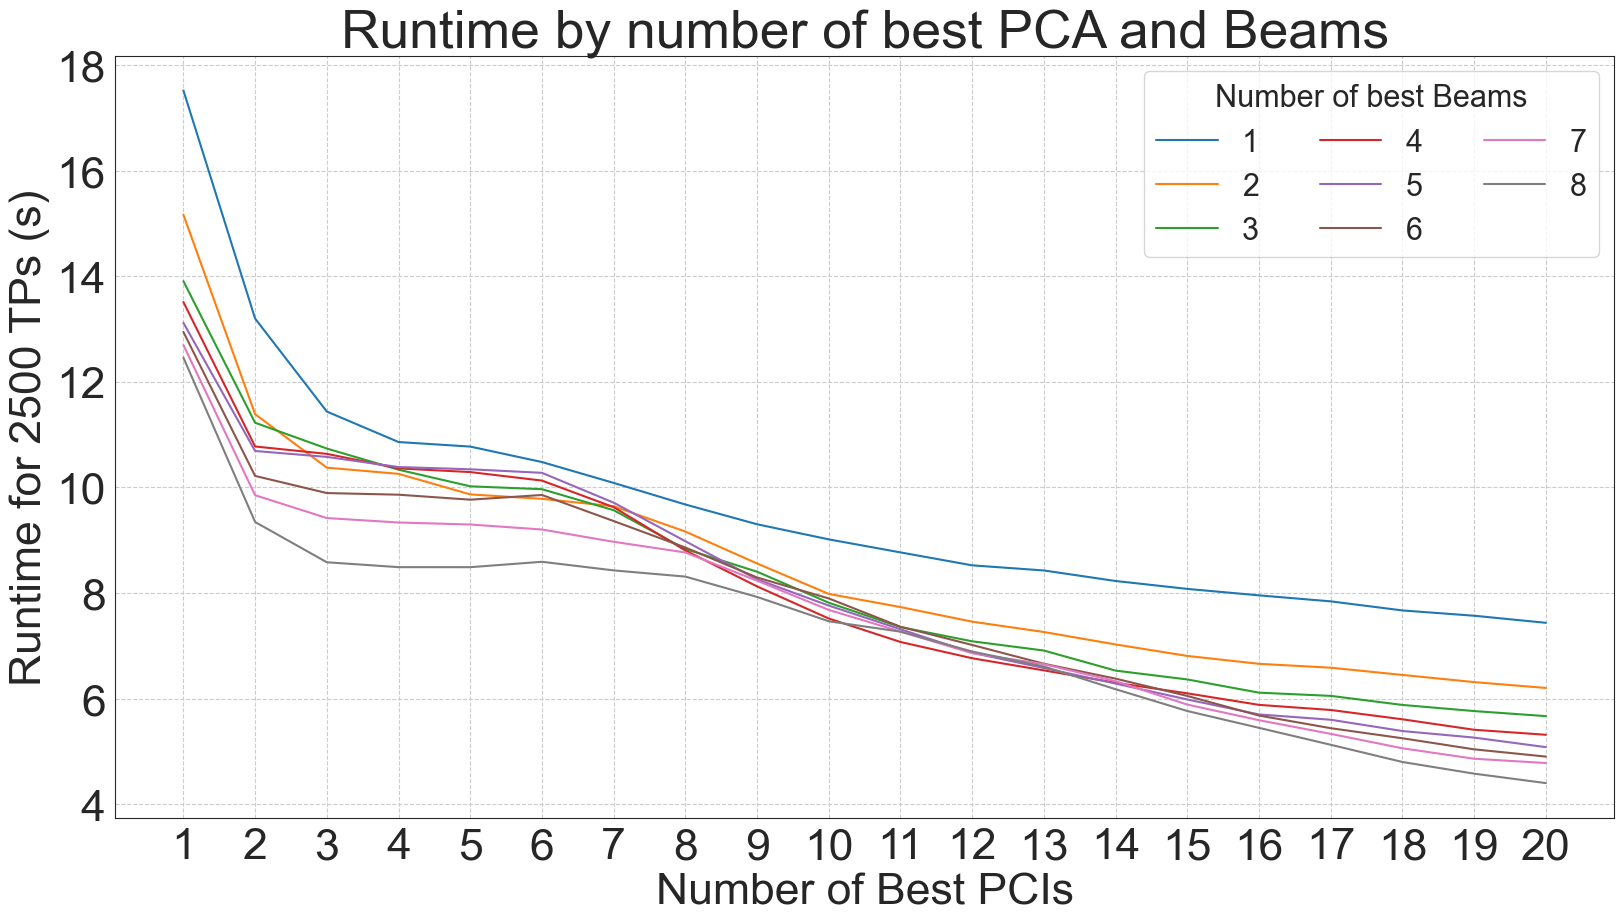

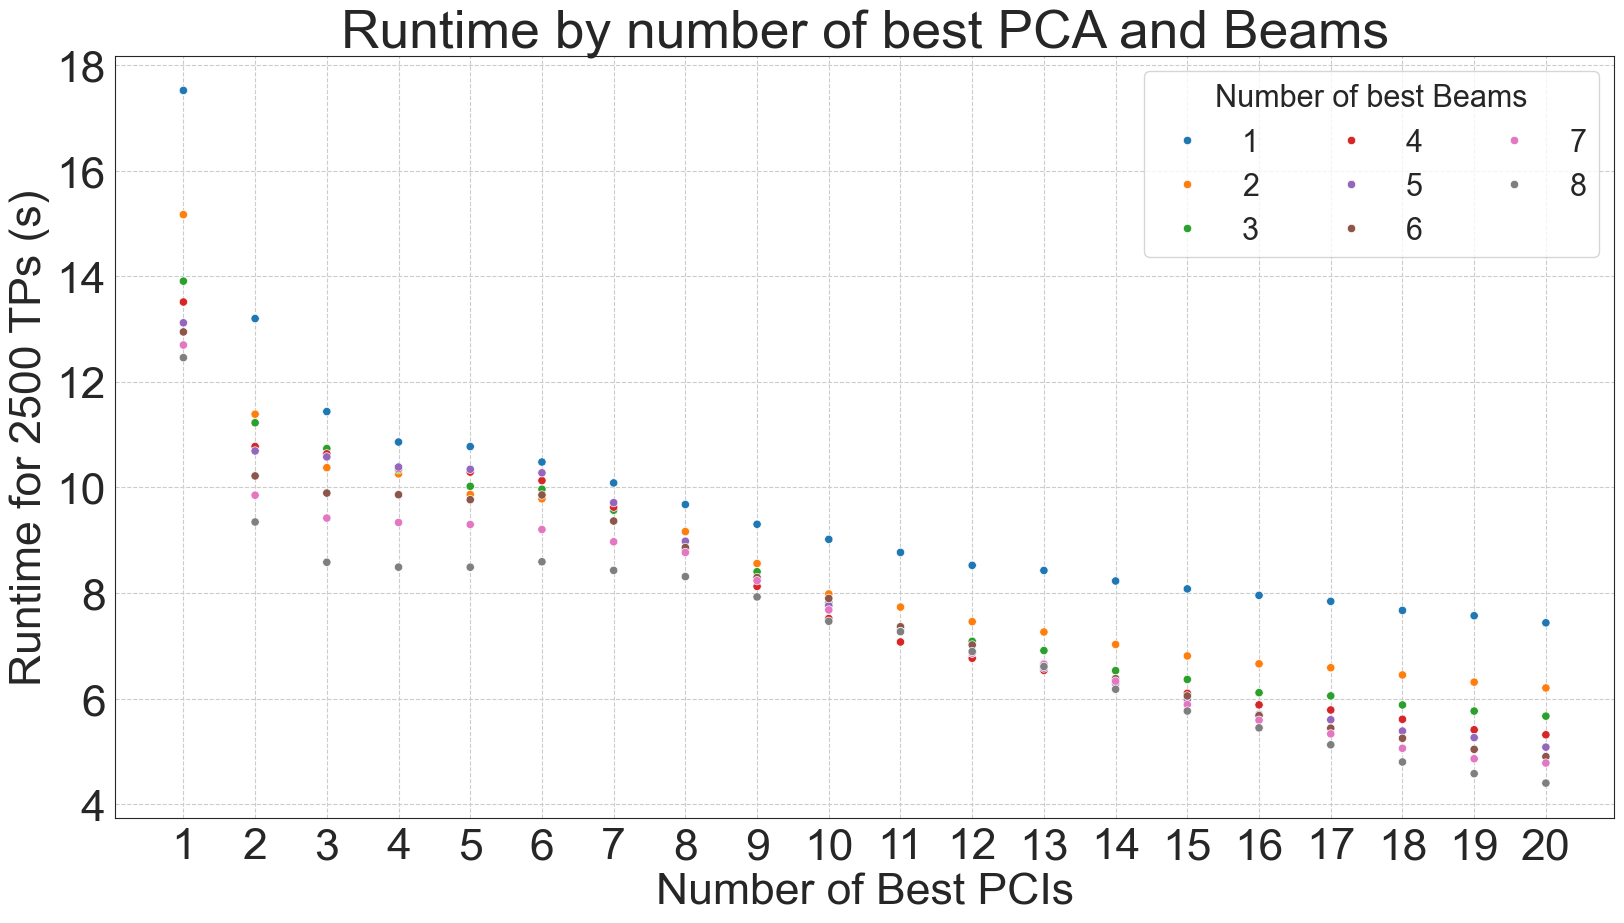

In [82]:
means = data_df.groupby(['n_best_beams', 'n_best_pcis'])['errors'].mean().reset_index()

categories = [str(i) for i in range(1, 21)]
means['n_best_pcis'] = pd.Categorical(means['n_best_pcis'], categories=categories)


def plot_runtime(df):
    plt.figure(figsize=(17, 10))
    #sns.scatterplot(means, x='n_best_pcis', y='runtime', hue='n_best_beams')
    sns.lineplot(data=df, x='n_best_pcis', y='errors', hue='n_best_beams')
    plt.grid(linestyle='--')

    plt.legend(title='Number of best Beams', fontsize=22, ncol=3, title_fontsize=22)
    plt.xlabel('Number of Best PCIs')
    plt.ylabel('Runtime for 2500 TPs (s)')
    plt.title('Runtime by number of best PCA and Beams')
    plt.tight_layout()

    plt.show()


def plot_runtime_scatter(df):
    plt.figure(figsize=(17, 10))
    #sns.scatterplot(means, x='n_best_pcis', y='errors', hue='n_best_beams')
    sns.scatterplot(data=df, x='n_best_pcis', y='errors', hue='n_best_beams')
    plt.grid(linestyle='--')

    plt.legend(title='Number of best Beams', fontsize=22, ncol=3, title_fontsize=22)
    plt.xlabel('Number of Best PCIs')
    plt.ylabel('Runtime for 2500 TPs (s)')
    plt.title('Runtime by number of best PCA and Beams')
    plt.tight_layout()

    plt.show()


plot_runtime(means)
plot_runtime_scatter(means)